# Manual Instagram + LLM comments

Self-contained project: `.env`, `browser_data`, logs, CDP helpers.

Login uses `INSTA_ID` / `INSTA_PASS` from `.env` when the profile is not already signed in. LLM writes comments only.

Call async helpers with `run(coro)`. Batch: `python main_test.py --target 10`


In [1]:
import asyncio
import concurrent.futures
import csv
import json
import re
import sys
import threading
from datetime import datetime, timezone
from pathlib import Path

from playwright.async_api import async_playwright

from IPython.display import Image as IPImage, display

from comment_llm import generate_comment
from config import (
    BROWSER_DATA_DIR,
    CSV_PATH,
    LOG_PATH,
    WINDOW_HEIGHT,
    WINDOW_WIDTH,
    ensure_browser_cdp,
    load_env,
)

load_env()

_loop = None
_thread = None


def run(coro):
    """Run an async coroutine. Safe in scripts and in Jupyter on Windows."""
    global _loop, _thread
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        if sys.platform == "win32":
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        return asyncio.run(coro)

    if _loop is None or not _loop.is_running():
        ready = concurrent.futures.Future()

        def _runner():
            global _loop
            if sys.platform == "win32":
                asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
            _loop = asyncio.new_event_loop()
            asyncio.set_event_loop(_loop)
            ready.set_result(True)
            _loop.run_forever()

        _thread = threading.Thread(target=_runner, daemon=True)
        _thread.start()
        ready.result()

    return asyncio.run_coroutine_threadsafe(coro, _loop).result()


def load_comment_log() -> list:
    if LOG_PATH.exists():
        try:
            return json.loads(LOG_PATH.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            return []
    return []


def already_seen(post_id: str = "", username: str = "", caption: str = "") -> dict | None:
    """Return the log row if we've already processed this post."""
    for row in load_comment_log():
        if post_id and row.get("post_id") and row["post_id"] == post_id:
            return row
        if (
            not post_id
            and username
            and row.get("username") == username
            and (row.get("caption") or "") == (caption or "")
        ):
            return row
    return None


def log_post(
    *,
    post_id: str,
    username: str,
    caption: str,
    comment: str,
    relevant: bool | None = None,
) -> dict:
    """Upsert a post into comment_log.json and comment_log.csv."""
    now_local = datetime.now().astimezone()
    now_utc = datetime.now(timezone.utc)
    rows = load_comment_log()
    entry = {
        "datetime": now_local.strftime("%Y-%m-%d %H:%M:%S %z"),
        "datetime_utc": now_utc.strftime("%Y-%m-%d %H:%M:%S UTC"),
        "ts": now_utc.isoformat(),
        "post_id": post_id or "",
        "username": username or "",
        "caption": caption or "",
        "comment": comment or "",
        "relevant": relevant,
    }
    replaced = False
    for i, row in enumerate(rows):
        same_id = entry["post_id"] and row.get("post_id") == entry["post_id"]
        same_text = (
            not entry["post_id"]
            and row.get("username") == entry["username"]
            and (row.get("caption") or "") == entry["caption"]
        )
        if same_id or same_text:
            rows[i] = {**row, **entry}
            replaced = True
            break
    if not replaced:
        rows.append(entry)

    LOG_PATH.write_text(json.dumps(rows, indent=2, ensure_ascii=False), encoding="utf-8")

    fields = [
        "datetime",
        "datetime_utc",
        "ts",
        "post_id",
        "username",
        "caption",
        "comment",
        "relevant",
    ]
    with CSV_PATH.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        for row in rows:
            w.writerow({k: row.get(k, "") for k in fields})

    return entry


pw = browser = page = None
LAST = {"username": "", "caption": "", "image": None, "comment": "", "post_id": ""}
print(f"Ready. Log: {LOG_PATH.resolve()} ({len(load_comment_log())} posts)")

Ready. Log: D:\StorageData\Repos\browseruse\comment_log.json (0 posts)


## 1. Open / reuse browser

In [2]:
async def connect():
    global pw, browser, page
    cdp = ensure_browser_cdp()
    pw = await async_playwright().start()
    browser = await pw.chromium.connect_over_cdp(cdp)
    ctx = browser.contexts[0] if browser.contexts else await browser.new_context()
    page = ctx.pages[0] if ctx.pages else await ctx.new_page()
    await page.set_viewport_size({"width": WINDOW_WIDTH, "height": WINDOW_HEIGHT})
    return cdp, page.url


cdp, url = run(connect())
print(f"Connected: {cdp}")
print(f"URL: {url}")
print(f"Profile: {BROWSER_DATA_DIR}")

Launching Chrome with CDP on port 9222...
Chrome CDP ready: http://127.0.0.1:9222
Connected: http://127.0.0.1:9222
URL: chrome://new-tab-page/
Profile: D:\StorageData\Repos\browseruse\browser_data


## 2. Instagram home + login

Uses `INSTA_ID` / `INSTA_PASS` from `.env` if the Chrome profile is not already signed in.

In [3]:
async def goto_home():
    await page.goto("https://www.instagram.com/", wait_until="domcontentloaded")
    await page.wait_for_timeout(1500)
    return page.url


async def is_logged_in() -> bool:
    url = (page.url or "").lower()
    if "accounts/login" in url or "/login" in url:
        return False
    user_box = page.locator('input[name="username"]')
    if await user_box.count() and await user_box.first.is_visible():
        return False
    for sel in (
        'svg[aria-label="Home"]',
        'svg[aria-label="Search"]',
        'svg[aria-label="New post"]',
    ):
        if await page.locator(sel).count():
            return True
    return await page.locator("article").count() > 0


async def login_if_needed():
    from config import INSTA_ID, INSTA_PASS

    await goto_home()
    # dismiss runs after helpers cell; call light dismiss here
    for label in ("Not Now", "Not now", "Decline optional cookies", "Allow all cookies"):
        btn = page.get_by_role("button", name=label)
        if await btn.count():
            try:
                await btn.first.click(timeout=1500)
                await page.wait_for_timeout(400)
            except Exception:
                pass

    if await is_logged_in():
        return {"status": "already_logged_in", "url": page.url, "user": INSTA_ID or ""}

    if not INSTA_ID or not INSTA_PASS:
        raise RuntimeError("Not logged in and INSTA_ID/INSTA_PASS missing from .env")

    user_box = page.locator('input[name="username"]')
    if not (await user_box.count() and await user_box.first.is_visible()):
        await page.goto(
            "https://www.instagram.com/accounts/login/",
            wait_until="domcontentloaded",
        )
        await page.wait_for_timeout(1500)
        user_box = page.locator('input[name="username"]')

    if not await user_box.count():
        raise RuntimeError("Login form not found")

    await user_box.first.fill(INSTA_ID)
    await page.locator('input[name="password"]').first.fill(INSTA_PASS)
    submit = page.locator('button[type="submit"]')
    if await submit.count():
        await submit.first.click()
    else:
        await page.get_by_role("button", name="Log in", exact=True).first.click()

    await page.wait_for_timeout(4500)
    for label in ("Not Now", "Not now"):
        btn = page.get_by_role("button", name=label)
        if await btn.count():
            try:
                await btn.first.click(timeout=2000)
                await page.wait_for_timeout(400)
            except Exception:
                pass

    if not await is_logged_in():
        raise RuntimeError("Login failed — check credentials or 2FA")
    return {"status": "logged_in", "url": page.url, "user": INSTA_ID}


print(run(login_if_needed()))
print("Ready for helpers / commenting.")

https://www.instagram.com/
Log in manually in Chrome if needed.


## 3. Helpers

In [4]:
async def dismiss():
    clicked = []
    for label in ("Not Now", "Not now", "Decline optional cookies", "Allow all cookies"):
        btn = page.get_by_role("button", name=label)
        if await btn.count():
            try:
                await btn.first.click(timeout=1500)
                await page.wait_for_timeout(400)
                clicked.append(label)
            except Exception:
                pass
    return clicked


async def _comment_btn(root):
    btn = root.locator('svg[aria-label="Comment"]').first
    if await btn.count():
        return btn
    btn = root.get_by_role("button", name="Comment").first
    if await btn.count():
        return btn
    return None


async def _post_id_from(el) -> str:
    if el is None:
        return ""
    return await el.evaluate(
        """(node) => {
          const hrefs = [...node.querySelectorAll('a[href*="/p/"], a[href*="/reel/"]')]
            .map(a => a.getAttribute('href') || '');
          for (const href of hrefs) {
            const m = href.match(/\\/(p|reel)\\/([^\\/?#]+)/);
            if (m) return m[2];
          }
          return '';
        }"""
    )


async def _dialog_post_id() -> str:
    dialog = page.locator('div[role="dialog"]').first
    if await dialog.count() == 0:
        return ""
    handle = await dialog.element_handle()
    pid = await _post_id_from(handle)
    if pid:
        return pid
    return await page.evaluate(
        """() => {
          const m = (location.pathname + ' ' + location.href).match(/\\/(p|reel)\\/([^\\/?#]+)/);
          return m ? m[2] : '';
        }"""
    )


async def close_post():
    """Click the Close (X) button on the open post dialog."""
    dialog = page.locator('div[role="dialog"]').first
    if await dialog.count() == 0:
        return "no dialog"

    close = dialog.locator('svg[aria-label="Close"]').first
    if await close.count() == 0:
        close = page.locator('svg[aria-label="Close"]').first
    if await close.count() == 0:
        close = dialog.get_by_role("button", name="Close").first
    if await close.count() == 0:
        close = page.get_by_role("button", name="Close").first

    if await close.count():
        try:
            await close.click(timeout=3000)
        except Exception:
            # Parent clickable often wraps the SVG
            await close.locator("xpath=..").click(timeout=3000)
    else:
        await page.keyboard.press("Escape")

    await page.wait_for_timeout(600)
    try:
        await dialog.wait_for(state="hidden", timeout=5000)
    except Exception:
        pass
    return "closed"


# Keep old name as alias
async def escape():
    return await close_post()


async def open_via_comment(index: int = 0, max_scrolls: int = 12):
    """Legacy: open feed article by index. Prefer open_next_unseen()."""
    dialog = page.locator('div[role="dialog"]')
    if await dialog.count():
        await close_post()

    for _ in range(max_scrolls + 1):
        articles = page.locator("article")
        n = await articles.count()
        if n > index:
            target = articles.nth(index)
            comment = await _comment_btn(target)
            if comment is not None:
                try:
                    await comment.scroll_into_view_if_needed(timeout=2000)
                    await page.wait_for_timeout(300)
                    await comment.click(timeout=3000)
                    break
                except Exception:
                    pass
        await page.mouse.wheel(0, 450)
        await page.wait_for_timeout(500)
    else:
        raise RuntimeError(f"Comment button not found for post index={index} after scrolling")

    await page.wait_for_timeout(1200)
    await dialog.first.wait_for(state="visible", timeout=15000)
    return {"status": "opened", "post_id": await _dialog_post_id()}


async def open_next_unseen(max_scrolls: int = 24):
    """
    Open the next feed post whose post_id is not in comment_log.json.
    Scrolls the feed until an unseen Comment button is found.
    """
    seen_ids = {r.get("post_id") for r in load_comment_log() if r.get("post_id")}
    dialog = page.locator('div[role="dialog"]')
    if await dialog.count():
        await close_post()

    tried: set[str] = set()

    for _ in range(max_scrolls + 1):
        articles = page.locator("article")
        n = await articles.count()
        for i in range(n):
            target = articles.nth(i)
            pid = ""
            try:
                handle = await target.element_handle()
                if handle:
                    pid = await _post_id_from(handle) or ""
            except Exception:
                pid = ""

            if pid and (pid in seen_ids or pid in tried):
                continue

            comment = await _comment_btn(target)
            if comment is None:
                continue

            try:
                await comment.scroll_into_view_if_needed(timeout=2000)
                await page.wait_for_timeout(250)
                await comment.click(timeout=3000)
                await page.wait_for_timeout(1000)
                await dialog.first.wait_for(state="visible", timeout=12000)
            except Exception:
                continue

            opened_id = await _dialog_post_id() or pid
            if opened_id and opened_id in seen_ids:
                tried.add(opened_id)
                await close_post()
                continue

            if opened_id:
                tried.add(opened_id)
            await dismiss_more_menu()
            return {"status": "opened", "post_id": opened_id}

        await page.mouse.wheel(0, 500)
        await page.wait_for_timeout(550)

    raise RuntimeError("No unseen posts found (by post_id) after scrolling")


async def dismiss_more_menu():
    """Close the three-dots 'More options' sheet if it is open."""
    # Action sheet / nested dialog with Cancel or known menu items
    cancel = page.get_by_role("button", name="Cancel", exact=True)
    if await cancel.count():
        try:
            await cancel.last.click(timeout=2000)
            await page.wait_for_timeout(400)
            return "closed via Cancel"
        except Exception:
            pass

    # Nested dialog that is the options menu (not the main post)
    menus = page.locator('div[role="dialog"]')
    n = await menus.count()
    if n >= 2:
        # Topmost dialog is usually the options sheet
        top = menus.nth(n - 1)
        for label in ("Cancel", "Close", "Not Now"):
            btn = top.get_by_role("button", name=label, exact=True)
            if await btn.count():
                try:
                    await btn.first.click(timeout=2000)
                    await page.wait_for_timeout(400)
                    return f"closed via {label}"
                except Exception:
                    pass
        await page.keyboard.press("Escape")
        await page.wait_for_timeout(400)
        return "closed via Escape"

    # Detect More options sheet still present by menu actions
    for label in ("Report", "About this account", "Copy link", "Embed"):
        if await page.get_by_role("button", name=label, exact=True).count():
            await page.keyboard.press("Escape")
            await page.wait_for_timeout(400)
            return "closed via Escape (menu items)"
    return "ok"


async def _expand_caption():
    """Click caption '... more' only — never the three-dots More options."""
    await dismiss_more_menu()

    root = page.locator('div[role="dialog"]').first
    if await root.count() == 0:
        root = page.locator("article").first

    # Exact text only — "more" as substring matches aria-label "More options"
    for pattern in (r"^more$", r"^… more$", r"^\.\.\. more$", r"^See more$"):
        more = root.get_by_role("button", name=re.compile(pattern, re.I))
        if await more.count() == 0:
            more = root.locator(f"span").filter(has_text=re.compile(pattern, re.I))
        if await more.count() == 0:
            continue
        # Skip anything that is the overflow menu
        for i in range(await more.count()):
            el = more.nth(i)
            label = (await el.get_attribute("aria-label") or "").lower()
            if "option" in label or "more options" in label:
                continue
            try:
                await el.click(timeout=1500)
                await page.wait_for_timeout(400)
                await dismiss_more_menu()
                return
            except Exception:
                continue


async def extract():
    await dismiss_more_menu()
    await _expand_caption()
    await dismiss_more_menu()

    data = await page.evaluate(
        """() => {
          const dialog = document.querySelector('div[role="dialog"]') || document.querySelector('article');
          if (!dialog) return { error: 'No post dialog/article found. Open a post first.' };

          const userEl = dialog.querySelector('header a[href^="/"]') || dialog.querySelector('a[href^="/"][role="link"]');
          let username = (userEl?.getAttribute('href') || '').replaceAll('/', '').trim();
          if (!username) username = (userEl?.innerText || '').trim();

          let caption = '';
          const h1 = dialog.querySelector('h1');
          if (h1) caption = (h1.innerText || '').trim();
          const candidates = dialog.querySelectorAll('ul li span[dir="auto"], span[dir="auto"], h1');
          for (const s of candidates) {
            const t = (s.innerText || '').trim();
            if (!t) continue;
            if (t.toLowerCase() === username.toLowerCase()) continue;
            if (t === 'more' || t === '… more' || t === '... more') continue;
            if (t.length > caption.length) caption = t;
          }
          caption = caption.replace(/\\s*…?\\s*more$/i, '').trim();

          let image_url = '';
          let bestArea = 0;
          for (const img of dialog.querySelectorAll('img')) {
            const src = img.currentSrc || img.src || '';
            if (!src || src.startsWith('data:')) continue;
            const w = img.naturalWidth || img.width || 0;
            const h = img.naturalHeight || img.height || 0;
            const area = w * h;
            if (area > bestArea && w >= 100) {
              bestArea = area;
              image_url = src;
            }
          }
          if (!image_url) {
            const img = dialog.querySelector('article img') || dialog.querySelector('img[src*="cdninstagram"]');
            image_url = img?.currentSrc || img?.src || '';
          }

          let post_id = '';
          const hrefs = [
            ...[...dialog.querySelectorAll('a[href*="/p/"], a[href*="/reel/"]')].map(a => a.getAttribute('href') || ''),
            location.pathname,
            location.href,
          ];
          for (const href of hrefs) {
            const m = href.match(/\\/(p|reel)\\/([^\\/?#]+)/);
            if (m) { post_id = m[2]; break; }
          }

          return { username, caption, image_url, post_id };
        }"""
    )
    if data.get("error"):
        raise RuntimeError(data["error"])

    if data.get("image_url"):
        raw = await page.evaluate(
            """async (url) => {
              const res = await fetch(url);
              const buf = await res.arrayBuffer();
              return Array.from(new Uint8Array(buf));
            }""",
            data["image_url"],
        )
        image = bytes(raw)
    else:
        loc = page.locator('div[role="dialog"]').first
        image = (
            await loc.screenshot(type="jpeg", quality=85)
            if await loc.count()
            else await page.screenshot(type="jpeg", quality=85)
        )
    return {
        "username": data.get("username") or "",
        "caption": data.get("caption") or "",
        "image": image,
        "post_id": data.get("post_id") or "",
    }


async def submit(text: str):
    """Type the comment and click the blue Post button in the open dialog."""
    await dismiss_more_menu()

    dialog = page.locator('div[role="dialog"]').first
    scope = dialog if await dialog.count() else page

    box = scope.locator(
        'textarea[aria-label*="Add a comment"], '
        'textarea[placeholder*="Add a comment"], '
        'div[role="textbox"][contenteditable="true"][aria-label*="Add a comment"]'
    )
    if await box.count() == 0:
        box = scope.get_by_role("textbox", name=re.compile(r"add a comment", re.I))
    if await box.count() == 0:
        raise RuntimeError("Comment textbox not found")

    target = box.first
    await target.click()
    await page.wait_for_timeout(200)
    await target.fill("")
    try:
        await target.press_sequentially(text, delay=12)
    except Exception:
        await target.fill(text)
        await target.dispatch_event("input")
    await page.wait_for_timeout(700)

    await dismiss_more_menu()

    post_btn = scope.locator("form").get_by_role("button", name="Post", exact=True)
    if await post_btn.count() == 0:
        post_btn = scope.get_by_role("button", name="Post", exact=True)
    if await post_btn.count() == 0:
        post_btn = scope.locator('[role="button"]', has_text=re.compile(r"^Post$"))

    if await post_btn.count() == 0:
        raise RuntimeError("Blue Post button not found")

    clicked = False
    for i in range(await post_btn.count() - 1, -1, -1):
        btn = post_btn.nth(i)
        try:
            if not await btn.is_visible():
                continue
            await btn.click(timeout=4000, force=False)
            clicked = True
            break
        except Exception:
            try:
                await btn.click(timeout=4000, force=True)
                clicked = True
                break
            except Exception:
                continue
    if not clicked:
        raise RuntimeError("Could not click blue Post button")

    await page.wait_for_timeout(1500)
    return "submitted"


print("Helpers ready.")

Helpers ready.


In [5]:
print(run(dismiss()))

[]


## 4. Open next unseen post + extract

Opens the next feed post whose `post_id` is **not** in `comment_log.json` (scrolls past already-logged ones), then extracts image / caption / id.

{'status': 'opened', 'post_id': 'DaP9eTbiKT6'}
post_id:  DaP9eTbiKT6
Username: @dubaifuture
Caption:
The inaugural Dubai Future Forum Insights Report carries the conversation forward beyond the Forum, offering leaders and future-focused communities a set of signals and reflections to think with throughout the year. Rooted in human judgement rather than automated transcription, it reflects a view of foresight as a fundamentally human practice shaped by creativity, responsibility, and collective sense-making.

Dive into the full report, link in bio.

#DubaiFuture #DFForum25


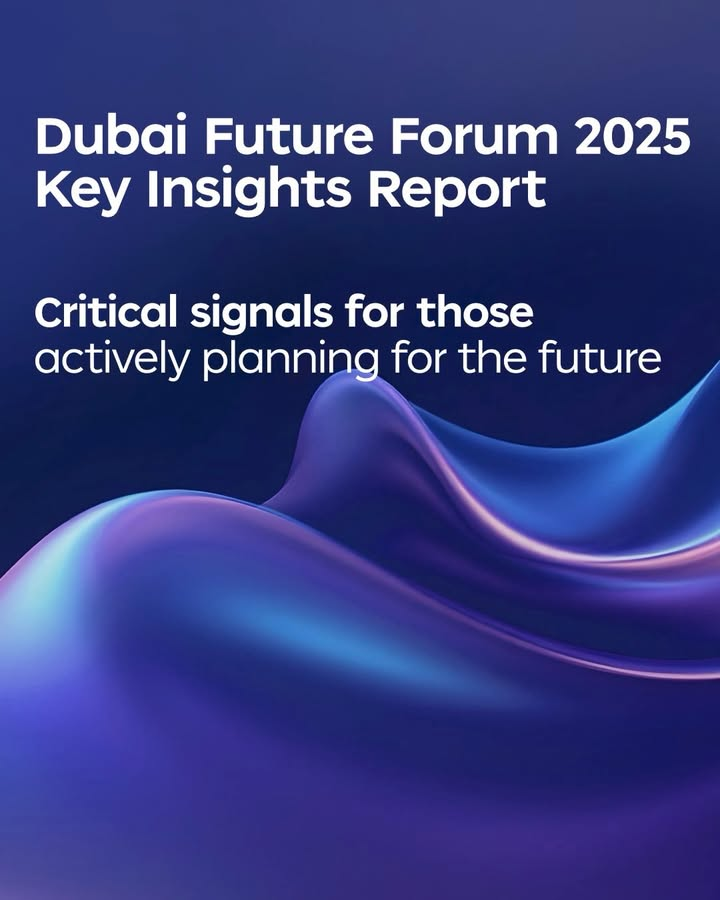

In [6]:
opened = run(open_next_unseen())
print(opened)
extracted = run(extract())
LAST.update({**extracted, "comment": ""})
if not LAST["post_id"] and opened.get("post_id"):
    LAST["post_id"] = opened["post_id"]

print(f"post_id:  {LAST['post_id'] or '(none)'}")
print(f"Username: @{LAST['username']}")
print(f"Caption:\n{LAST['caption'][:500]}")

seen = already_seen(LAST["post_id"], LAST["username"], LAST["caption"])
if seen:
    when = seen.get("datetime") or seen.get("ts") or "?"
    print(f"\nSKIP — already logged at {when} (comment={seen.get('comment')!r})")
    print(run(close_post()))
else:
    display(IPImage(data=LAST["image"]))

## 5. Ask LLM for comment

In [7]:
if already_seen(LAST["post_id"], LAST["username"], LAST["caption"]):
    print("Already logged — skip LLM.")
    print(run(close_post()))
else:
    result = generate_comment(
        username=LAST["username"],
        caption=LAST["caption"],
        image=LAST["image"],
    )
    LAST["comment"] = result.get("comment") or ""
    LAST["relevant"] = result.get("relevant")
    print(f"Relevant: {result.get('relevant')}")
    print(f"Reason:   {result.get('reason')}")
    print(f"Comment:  {LAST['comment']}")
    if not LAST["comment"]:
        log_post(
            post_id=LAST["post_id"],
            username=LAST["username"],
            caption=LAST["caption"],
            comment="",
            relevant=bool(result.get("relevant")),
        )
        print(f"Logged as skipped (no comment) → {LOG_PATH}")
        print(run(close_post()))
        print("Closed. Re-run step 4 for the next unseen post.")

LM Studio OK: http://26.148.182.120:1234/v1 | model: google/gemma-4-e2b
Relevant: True
Reason:   Connects CTech's mission to the theme of future planning in the UAE.
Comment:  CTech is deeply committed to fostering the future of the UAE through innovation and human-centric planning. We support these critical insights for building a prosperous tomorrow.


## 6. Submit / close

In [8]:
prev = already_seen(LAST["post_id"], LAST["username"], LAST["caption"])
if prev and prev.get("comment"):
    print("Already commented — closing.")
    print(run(close_post()))
elif not LAST.get("comment"):
    print("No comment to post — closing.")
    log_post(
        post_id=LAST["post_id"],
        username=LAST["username"],
        caption=LAST["caption"],
        comment="",
        relevant=LAST.get("relevant", False),
    )
    print(run(close_post()))
else:
    print(run(submit(LAST["comment"])))
    log_post(
        post_id=LAST["post_id"],
        username=LAST["username"],
        caption=LAST["caption"],
        comment=LAST["comment"],
        relevant=LAST.get("relevant", True),
    )
    print(f"Logged → {LOG_PATH} / {CSV_PATH}")
    print(run(close_post()))
    print("Closed. Re-run step 4 for the next unseen post.")

submitted
Logged → comment_log.json / comment_log.csv
closed
Closed. Re-run step 4 for the next unseen post.


In [ ]:
# Optional: close if a dialog is still open
print(run(close_post()))
print("Ready for step 4 (next unseen post_id).")

## Disconnect

In [ ]:
async def disconnect():
    global pw, browser, page
    if browser:
        await browser.close()
    if pw:
        await pw.stop()
    browser = page = pw = None


run(disconnect())
print("Disconnected (Chrome CDP may stay open).")